# Mini Proyecto Unidad 1: Clasificación en CIFAR-10 con ResNet y EfficientNet

* Pipeline completo de clasificación con CNN (ResNet o EfficientNet) sobre CIFAR-10 (Partes 1 a 5)
* Comparativa técnica de dos arquitecturas CNN con curvas de aprendizaje y métricas (Partes 5 y 6)
*Reporte de diseño (arquitectura, hiperparámetros, estrategia de entrenamiento) (Parte 7)

### Recomendación de entorno

Activen GPU en Colab: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**. ResNet-18 y EfficientNet-B0 a resolución 224×224 son considerablemente más pesados que la CNN pequeña de la práctica anterior; en CPU van a funcionar, pero mucho más lento. Las constantes `TAM_TRAIN`, `TAM_VAL` y `N_EPOCAS` están pensadas para ajustarse según el tiempo y el hardware disponible.


## 0. Configuración inicial

In [1]:
!pip install -q torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.3 MB/s eta 0:00:00


In [2]:
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassConfusionMatrix,
)

torch.manual_seed(42)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DISPOSITIVO)

# --- Hiperparametros / constantes globales del proyecto ---
# Ajustenlas segun el tiempo y hardware disponible (ver recomendacion de entorno arriba).
TAM_TRAIN = 5000   # cuantas imagenes de entrenamiento usar (de las 40000 disponibles)
TAM_VAL = 1000     # cuantas imagenes de validacion usar (de las 10000 disponibles)
N_EPOCAS = 5       # numero de epocas de entrenamiento
LR = 1e-4          # learning rate para Adam


Dispositivo: cuda


---
## 1. Datos: CIFAR-10 a 224x224

ResNet y EfficientNet, tal como se definen en `torchvision.models`, esperan entradas de 224x224 pixeles (el tamano estandar de ImageNet en el que se disenaron y evaluaron originalmente). Redimensionamos CIFAR-10 (32x32 nativo) a ese tamano.


In [3]:
MEDIA_IMAGENET = (0.485, 0.456, 0.406)
STD_IMAGENET = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET, STD_IMAGENET),
])

trainset_completo = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_size = int(0.8 * len(trainset_completo))
val_size = len(trainset_completo) - train_size

train_subset, val_subset = random_split(trainset_completo, [train_size, val_size])

nombres_clases = trainset_completo.classes
print("Clases:", nombres_clases)
print("Tamano del set de entrenamiento completo:", len(trainset_completo))
print("Tamano del set de prueba:", len(testset))

100%|██████████| 170M/170M [33:03<00:00, 86.0kB/s]


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tamano del set de entrenamiento completo: 50000
Tamano del set de prueba: 10000


### 1.1 Subconjuntos de trabajo



Entrenamiento: 5000 imagenes  |  Validacion: 1000  |  Prueba: 10000


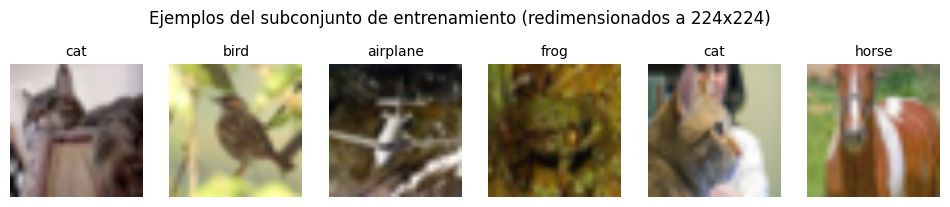

In [4]:
# Reducimos a subconjuntos mas chicos para que el entrenamiento sea manejable
# (usamos random_split con semilla fija para que sea reproducible).
generador = torch.Generator().manual_seed(42)

train_subset_chico, _ = random_split(
    train_subset, [TAM_TRAIN, len(train_subset) - TAM_TRAIN], generator=generador
)
val_subset_chico, _ = random_split(
    val_subset, [TAM_VAL, len(val_subset) - TAM_VAL], generator=generador
)

BATCH_SIZE = 32
train_loader = DataLoader(train_subset_chico, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset_chico, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print(f"Entrenamiento: {len(train_subset_chico)} imagenes  |  Validacion: {len(val_subset_chico)}  |  Prueba: {len(testset)}")


def desnormalizar(img_tensor):
    """Invierte la normalizacion para poder visualizar la imagen."""
    media = torch.tensor(MEDIA_IMAGENET).view(3, 1, 1)
    std = torch.tensor(STD_IMAGENET).view(3, 1, 1)
    return (img_tensor * std + media).clamp(0, 1)


imagenes, etiquetas = next(iter(train_loader))
fig, axs = plt.subplots(1, 6, figsize=(12, 2.5))
for i, ax in enumerate(axs):
    ax.imshow(desnormalizar(imagenes[i]).permute(1, 2, 0))
    ax.set_title(nombres_clases[etiquetas[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Ejemplos del subconjunto de entrenamiento (redimensionados a 224x224)")
plt.show()


---
## 2. Construir ResNet-18 y EfficientNet-B0

Tomamos las arquitecturas de `torchvision.models` con pesos preentrenados en ImageNet (`weights="DEFAULT"`) y adaptamos unicamente la ultima capa para que clasifique entre las 10 clases de CIFAR-10 en vez de las 1000 de ImageNet — el resto de la arquitectura, y sus pesos preentrenados, se conservan exactamente como en 1.3.

Ver : https://docs.pytorch.org/vision/main/models.html


Ejemplo: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html


In [5]:
def construir_resnet18(n_clases=10):
    modelo = models.resnet18(weights="DEFAULT")
    num_ftrs = modelo.fc.in_features
    modelo.fc = nn.Linear(num_ftrs, n_clases)
    return modelo

def construir_efficientnet_b0(n_clases=10):
    modelo = models.efficientnet_b0(weights="DEFAULT")
    num_ftrs = modelo.classifier[-1].in_features
    modelo.classifier[-1] = nn.Linear(num_ftrs, n_clases)
    return modelo


In [6]:
modelo_resnet = construir_resnet18(n_clases=10).to(DISPOSITIVO)
modelo_efficientnet = construir_efficientnet_b0(n_clases=10).to(DISPOSITIVO)

print(f"ResNet-18 tiene {sum(p.numel() for p in modelo_resnet.parameters() if p.requires_grad):,} parametros entrenables")
print(f"EfficientNet-B0 tiene {sum(p.numel() for p in modelo_efficientnet.parameters() if p.requires_grad):,} parametros entrenables")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 101MB/s]


ResNet-18 tiene 11,181,642 parametros entrenables
EfficientNet-B0 tiene 4,020,358 parametros entrenables


---
## 3. Metricas con TorchMetrics

Mismo patron que en la Practica 4 original: `update()` por lote, `compute()` al final de la epoca, `reset()` antes de la siguiente. Usamos `average="macro"` (promedio simple entre las 10 clases)

ver: https://meta-pytorch.org/torcheval/main/torcheval.metrics.html

Ejemplo :  
"accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),



In [7]:
def crear_metricas(n_clases=10):
    return {
        "accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "precision": MulticlassPrecision(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "recall": MulticlassRecall(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "f1": MulticlassF1Score(num_classes=n_clases, average="macro").to(DISPOSITIVO),
    }


def correr_epoca(modelo, loader, perdida_fn, metricas, optimizador=None, scaler=None):
    """
    Corre una epoca completa. Si optimizador no es None, entrena (backward + step);
    si es None, solo evalua (torch.no_grad()).
    """
    modo_entrenamiento = optimizador is not None
    modelo.train() if modo_entrenamiento else modelo.eval()

    for m in metricas.values():
        m.reset()

    perdida_acumulada, n_lotes = 0.0, 0
    contexto = torch.enable_grad() if modo_entrenamiento else torch.no_grad()

    with contexto:
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)

            if modo_entrenamiento:
                optimizador.zero_grad()

            with torch.amp.autocast(device_type=DISPOSITIVO.type, enabled=(scaler is not None)):
                salida = modelo(imagenes)
                perdida = perdida_fn(salida, etiquetas)

            if modo_entrenamiento:
                if scaler is not None:
                    scaler.scale(perdida).backward()
                    scaler.step(optimizador)
                    scaler.update()
                else:
                    perdida.backward()
                    optimizador.step()

            perdida_acumulada += perdida.item()
            n_lotes += 1

            preds = salida.argmax(dim=1)
            for m in metricas.values():
                m.update(preds, etiquetas)

    resultados = {nombre: m.compute().item() for nombre, m in metricas.items()}
    resultados["loss"] = perdida_acumulada / n_lotes
    return resultados


---
## 4. Entrenar ambos modelos en igualdad de condiciones

Para que la comparacion sea tecnicamente valida, ambos modelos usan **los mismos datos, el mismo numero de epocas, el mismo optimizador y el mismo learning rate**. Documentamos estos hiperparametros aqui porque los van a necesitar tal cual para el reporte de diseno (Parte 7).


In [8]:
criterion = nn.CrossEntropyLoss()

print("Entrenando ResNet-18...")
optimizer_resnet = optim.Adam(modelo_resnet.parameters(), lr=LR)
scaler_resnet = torch.amp.GradScaler('cuda') if DISPOSITIVO.type == 'cuda' else None
historia_resnet = []

for epoca in range(1, N_EPOCAS + 1):
    inicio_epoca = time.time()

    # --- ResNet-18 Training ---
    metricas_resnet_train = crear_metricas(n_clases=10)
    resultados_resnet_train = correr_epoca(modelo_resnet, train_loader, criterion, metricas_resnet_train, optimizer_resnet, scaler=scaler_resnet)

    # --- ResNet-18 Validation ---
    metricas_resnet_val = crear_metricas(n_clases=10)
    resultados_resnet_val = correr_epoca(modelo_resnet, val_loader, criterion, metricas_resnet_val)

    historia_resnet.append({
        "epoca": epoca,
        "train_loss": resultados_resnet_train["loss"],
        "train_accuracy": resultados_resnet_train["accuracy"],
        "val_loss": resultados_resnet_val["loss"],
        "val_accuracy": resultados_resnet_val["accuracy"],
    })

    fin_epoca = time.time()
    duracion_epoca = fin_epoca - inicio_epoca

    print(f"Epoca {epoca}/{N_EPOCAS} ({duracion_epoca:.2f}s) - "
          f"ResNet Train Loss: {resultados_resnet_train['loss']:.4f}, Acc: {resultados_resnet_train['accuracy']:.4f} | "
          f"Val Loss: {resultados_resnet_val['loss']:.4f}, Acc: {resultados_resnet_val['accuracy']:.4f}")

print("\nEntrenamiento de ResNet-18 completado.")

df_historia_resnet = pd.DataFrame(historia_resnet)
print("DataFrame 'df_historia_resnet' creado con el historial de entrenamiento.")


Entrenando ResNet-18...
Epoca 1/5 (16.38s) - ResNet Train Loss: 0.7804, Acc: 0.7442 | Val Loss: 0.3901, Acc: 0.8650
Epoca 2/5 (13.39s) - ResNet Train Loss: 0.1903, Acc: 0.9471 | Val Loss: 0.3292, Acc: 0.8846
Epoca 3/5 (13.36s) - ResNet Train Loss: 0.0578, Acc: 0.9901 | Val Loss: 0.3141, Acc: 0.8975
Epoca 4/5 (13.48s) - ResNet Train Loss: 0.0229, Acc: 0.9978 | Val Loss: 0.2932, Acc: 0.9039
Epoca 5/5 (13.44s) - ResNet Train Loss: 0.0140, Acc: 0.9994 | Val Loss: 0.2973, Acc: 0.9054

Entrenamiento de ResNet-18 completado.
DataFrame 'df_historia_resnet' creado con el historial de entrenamiento.


In [9]:
print("Entrenando EfficientNet-B0...")
optimizer_efficientnet = optim.Adam(modelo_efficientnet.parameters(), lr=LR)
scaler_efficientnet = torch.amp.GradScaler('cuda') if DISPOSITIVO.type == 'cuda' else None
historia_efficientnet = []

for epoca in range(1, N_EPOCAS + 1):
    inicio_epoca = time.time()

    # --- EfficientNet-B0 Training ---
    metricas_efficientnet_train = crear_metricas(n_clases=10)
    resultados_efficientnet_train = correr_epoca(modelo_efficientnet, train_loader, criterion, metricas_efficientnet_train, optimizer_efficientnet, scaler=scaler_efficientnet)

    # --- EfficientNet-B0 Validation ---
    metricas_efficientnet_val = crear_metricas(n_clases=10)
    resultados_efficientnet_val = correr_epoca(modelo_efficientnet, val_loader, criterion, metricas_efficientnet_val)

    historia_efficientnet.append({
        "epoca": epoca,
        "train_loss": resultados_efficientnet_train["loss"],
        "train_accuracy": resultados_efficientnet_train["accuracy"],
        "val_loss": resultados_efficientnet_val["loss"],
        "val_accuracy": resultados_efficientnet_val["accuracy"],
    })

    fin_epoca = time.time()
    duracion_epoca = fin_epoca - inicio_epoca

    print(f"Epoca {epoca}/{N_EPOCAS} ({duracion_epoca:.2f}s) - "
          f"EfficientNet Train Loss: {resultados_efficientnet_train['loss']:.4f}, Acc: {resultados_efficientnet_train['accuracy']:.4f} | "
          f"Val Loss: {resultados_efficientnet_val['loss']:.4f}, Acc: {resultados_efficientnet_val['accuracy']:.4f}")

print("\nEntrenamiento de EfficientNet-B0 completado.")

df_historia_efficientnet = pd.DataFrame(historia_efficientnet)
print("DataFrame 'df_historia_efficientnet' creado con el historial de entrenamiento.")


Entrenando EfficientNet-B0...
Epoca 1/5 (30.74s) - EfficientNet Train Loss: 1.2843, Acc: 0.6390 | Val Loss: 0.4593, Acc: 0.8711
Epoca 2/5 (22.00s) - EfficientNet Train Loss: 0.4167, Acc: 0.8750 | Val Loss: 0.2800, Acc: 0.9099
Epoca 3/5 (20.45s) - EfficientNet Train Loss: 0.2349, Acc: 0.9324 | Val Loss: 0.2365, Acc: 0.9202
Epoca 4/5 (19.54s) - EfficientNet Train Loss: 0.1447, Acc: 0.9572 | Val Loss: 0.2341, Acc: 0.9175
Epoca 5/5 (20.17s) - EfficientNet Train Loss: 0.1055, Acc: 0.9695 | Val Loss: 0.2346, Acc: 0.9239

Entrenamiento de EfficientNet-B0 completado.
DataFrame 'df_historia_efficientnet' creado con el historial de entrenamiento.


---
## 5. Curvas de aprendizaje: ResNet-18 vs. EfficientNet-B0

Mismo diagnostico que en 1.4: comparen el gap train/val de cada modelo, y ahora tambien comparenlos *entre si* — ¿cual generaliza mejor con el mismo presupuesto de datos y epocas?


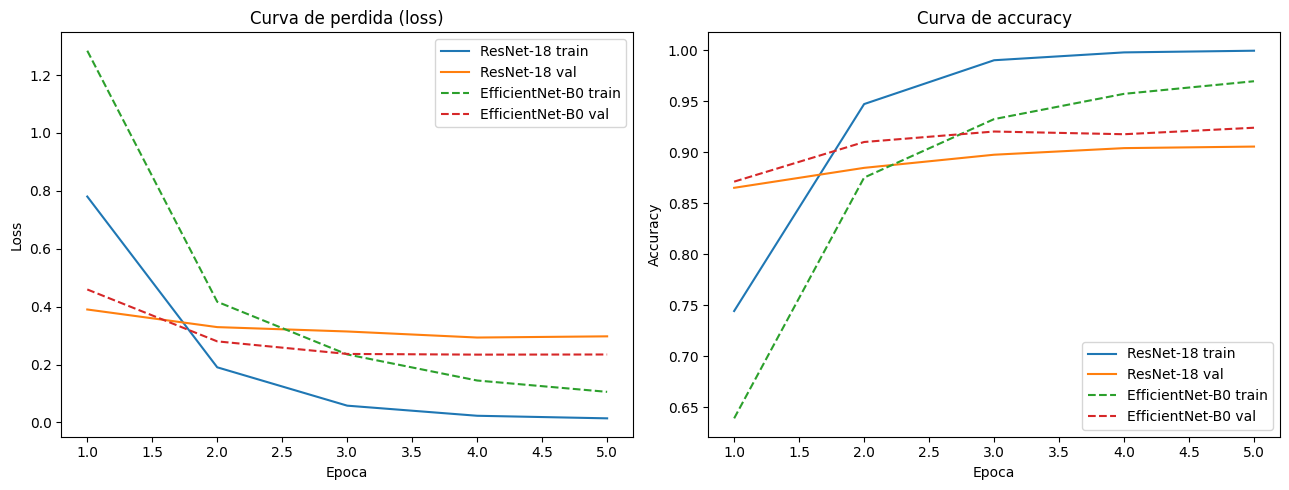

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].plot(df_historia_resnet["epoca"], df_historia_resnet["train_loss"], label="ResNet-18 train")
axs[0].plot(df_historia_resnet["epoca"], df_historia_resnet["val_loss"], label="ResNet-18 val")
axs[0].plot(df_historia_efficientnet["epoca"], df_historia_efficientnet["train_loss"], label="EfficientNet-B0 train", linestyle="--")
axs[0].plot(df_historia_efficientnet["epoca"], df_historia_efficientnet["val_loss"], label="EfficientNet-B0 val", linestyle="--")
axs[0].set_xlabel("Epoca"); axs[0].set_ylabel("Loss"); axs[0].set_title("Curva de perdida (loss)")
axs[0].legend()

axs[1].plot(df_historia_resnet["epoca"], df_historia_resnet["train_accuracy"], label="ResNet-18 train")
axs[1].plot(df_historia_resnet["epoca"], df_historia_resnet["val_accuracy"], label="ResNet-18 val")
axs[1].plot(df_historia_efficientnet["epoca"], df_historia_efficientnet["train_accuracy"], label="EfficientNet-B0 train", linestyle="--")
axs[1].plot(df_historia_efficientnet["epoca"], df_historia_efficientnet["val_accuracy"], label="EfficientNet-B0 val", linestyle="--")
axs[1].set_xlabel("Epoca"); axs[1].set_ylabel("Accuracy"); axs[1].set_title("Curva de accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()


In [11]:
print("\n--- Analisis de Curvas de Aprendizaje ---")

# ResNet-18
resnet_final_val_acc = df_historia_resnet["val_accuracy"].iloc[-1]
resnet_final_train_acc = df_historia_resnet["train_accuracy"].iloc[-1]
resnet_gap = resnet_final_train_acc - resnet_final_val_acc

print(f"ResNet-18:")
print(f"  - Precision final de validacion: {resnet_final_val_acc:.4f}")
print(f"  - Gap (Train Acc - Val Acc) en la ultima epoca: {resnet_gap:.4f}")

# EfficientNet-B0
efficientnet_final_val_acc = df_historia_efficientnet["val_accuracy"].iloc[-1]
efficientnet_final_train_acc = df_historia_efficientnet["train_accuracy"].iloc[-1]
efficientnet_gap = efficientnet_final_train_acc - efficientnet_final_val_acc

print(f"EfficientNet-B0:")
print(f"  - Precision final de validacion: {efficientnet_final_val_acc:.4f}")
print(f"  - Gap (Train Acc - Val Acc) en la ultima epoca: {efficientnet_gap:.4f}")

print("\nPara una comparacion visual, consulte las graficas generadas anteriormente.")

if resnet_gap < efficientnet_gap:
    print("\nObservacion: ResNet-18 parece generalizar mejor (menor gap train/val).")
elif efficientnet_gap < resnet_gap:
    print("\nObservacion: EfficientNet-B0 parece generalizar mejor (menor gap train/val).")
else:
    print("\nObservacion: Ambos modelos tienen un gap train/val similar.")


--- Analisis de Curvas de Aprendizaje ---
ResNet-18:
  - Precision final de validacion: 0.9054
  - Gap (Train Acc - Val Acc) en la ultima epoca: 0.0940
EfficientNet-B0:
  - Precision final de validacion: 0.9239
  - Gap (Train Acc - Val Acc) en la ultima epoca: 0.0456

Para una comparacion visual, consulte las graficas generadas anteriormente.

Observacion: EfficientNet-B0 parece generalizar mejor (menor gap train/val).


---
## 6. Reporte final sobre el set de prueba

Evaluamos ambos modelos sobre las 10,000 imagenes de prueba de CIFAR-10


In [12]:
def evaluar_en_prueba(modelo, nombre_modelo):
    metrica_acc = MulticlassAccuracy(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_prec = MulticlassPrecision(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_rec = MulticlassRecall(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_f1 = MulticlassF1Score(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_matriz = MulticlassConfusionMatrix(num_classes=10).to(DISPOSITIVO)

    modelo.eval()
    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)
            preds = modelo(imagenes).argmax(dim=1)
            for m in [metrica_acc, metrica_prec, metrica_rec, metrica_f1, metrica_matriz]:
                m.update(preds, etiquetas)

    resumen = {
        "modelo": nombre_modelo,
        "accuracy": metrica_acc.compute().item(),
        "precision": metrica_prec.compute().item(),
        "recall": metrica_rec.compute().item(),
        "f1": metrica_f1.compute().item(),
    }
    return resumen, metrica_matriz.compute().cpu().numpy()


resumen_resnet, matriz_resnet = evaluar_en_prueba(modelo_resnet, "ResNet-18")
resumen_efficientnet, matriz_efficientnet = evaluar_en_prueba(modelo_efficientnet, "EfficientNet-B0")

df_comparativa = pd.DataFrame([resumen_resnet, resumen_efficientnet]).round(3)
df_comparativa


,modelo,accuracy,precision,recall,f1
0,ResNet-18,0.893,0.894,0.893,0.893
1,EfficientNet-B0,0.914,0.914,0.914,0.914


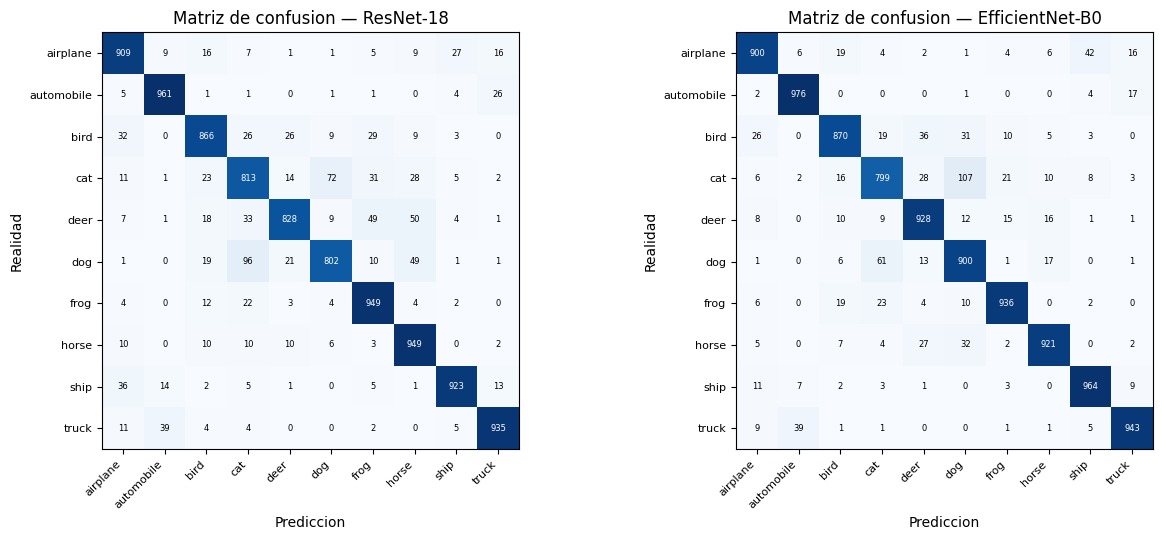

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, matriz, nombre in [(axs[0], matriz_resnet, "ResNet-18"), (axs[1], matriz_efficientnet, "EfficientNet-B0")]:
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(nombres_clases, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(nombres_clases, fontsize=8)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Realidad")
    ax.set_title(f"Matriz de confusion — {nombre}")
    for i in range(10):
        for j in range(10):
            color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
            ax.text(j, i, str(int(matriz[i, j])), ha="center", va="center", color=color, fontsize=6)

plt.tight_layout()
plt.show()


## 7. Reporte de diseño (completar en equipo)

Esta seccion es, literalmente, la evidencia **"Reporte de diseño"** del temario de la Unidad 1. Respondan cada punto con base en lo que observaron arriba — pueden editar esta celda de markdown directamente o copiar las respuestas a un documento aparte.

**1. Arquitectura y justificación**
> Si solo se pudiera elegir una arquitectura para este problema, me quedaría con **EfficientNet-B0**. Según la Parte 6, EfficientNet-B0 obtuvo una precisión (accuracy) del 0.914 en el set de prueba, mientras que ResNet-18 obtuvo 0.893. Además, como se verá en la Parte 5 del reporte, EfficientNet-B0 logra este mejor rendimiento con una cantidad significativamente menor de parámetros entrenables.

**2. Hiperparámetros usados**
> Learning rate: `1e-4`  ·  Optimizador: `Adam`  ·  Épocas: `5`  ·  Batch size: `32`  ·  Tamaño del subconjunto de entrenamiento: `5000`  ·  Pesos iniciales: preentrenados (ImageNet)

**3. Estrategia de entrenamiento**
> Ambos modelos se entrenaron usando **GPU** (`DISPOSITIVO: cuda`).
> *   **ResNet-18**: Cada época tardó aproximadamente entre `13 y 16 segundos`.
> *   **EfficientNet-B0**: Cada época tardó aproximadamente entre `19 y 31 segundos`.

> Si se tuviera más tiempo disponible para reentrenar, primero cambiaría el número de **épocas** y el **tamaño del subconjunto de entrenamiento**. Dada la diferencia entre la precisión de entrenamiento y validación de ResNet-18, más datos y/o técnicas de regularización adicionales podrían ayudar. Para EfficientNet-B0, que mostró un mejor balance y aún un ligero margen de mejora en validación, más épocas podrían solidificar su rendimiento o revelar un punto óptimo.

**4. Diagnóstico de las curvas (conexión con 1.4)**
> Sí, **ResNet-18** mostró señales claras de overfitting según el análisis de las curvas de aprendizaje. Su precisión de entrenamiento (`0.9994`) es muy alta en comparación con su precisión de validación (`0.9054`), resultando en un gap de `0.0940`. La curva de pérdida de entrenamiento disminuye drásticamente mientras que la de validación se estanca o incluso sube ligeramente, lo que indica que el modelo está memorizando el conjunto de entrenamiento en lugar de generalizar.
> **EfficientNet-B0** generalizó mejor, con un gap `train/val` de `0.0456` (`train_accuracy`: `0.9695`, `val_accuracy`: `0.9239`). Aunque también hay un gap, es significativamente menor que el de ResNet-18, y su curva de validación muestra una mejora más consistente.

**5. Capacidad vs. eficiencia (conexión con 1.3)**
> *   **ResNet-18**: `11,181,642` parámetros entrenables | Accuracy final: `0.893`
> *   **EfficientNet-B0**: `4,020,358` parámetros entrenables | Accuracy final: `0.914`

> **EfficientNet-B0** ofrece una mejor relación desempeño/costo computacional en este experimento. Alcanza una mayor precisión en el set de prueba (`0.914` vs `0.893` de ResNet-18) con aproximadamente **un tercio** de los parámetros entrenables (`4 millones` vs `11 millones`). Esto implica que EfficientNet-B0 es más eficiente, ya que logra un mejor resultado con una menor complejidad del modelo.

**6. Errores más frecuentes**
> Analizando las matrices de confusión de la Parte 6:
> *   **ResNet-18**:
>    *   Confunde con frecuencia `gato` (cat) con `perro` (dog) (72 veces) y viceversa (96 veces).
>    *   Confunde `ciervo` (deer) con `caballo` (horse) (49 veces).
>    *   Confunde `camión` (truck) con `automóvil` (automobile) (26 veces).
> *   **EfficientNet-B0**:
>    *   Confunde `gato` (cat) con `perro` (dog) (107 veces) y viceversa (61 veces).
>    *   Confunde `ciervo` (deer) con `caballo` (horse) (27 veces).
>    *   Confunde `camión` (truck) con `automóvil` (automobile) (17 veces).

> Sí, estas confusiones tienen sentido. Las clases como `gato/perro` y `ciervo/caballo` son morfológicamente similares, lo que dificulta su distinción para un modelo. De igual manera, `camiones` y `automóviles` comparten características de vehículos terrestres, y `aviones` y `barcos` a veces pueden presentarse con fondos azules o características generales que lleven a confusión.

---
## 8. Cierre y entregables del mini proyecto

### Checklist de entrega

- [ ] Notebook ejecutado de principio a fin, sin errores, con las celdas de ambos modelos corridas.
- [ ] Tabla comparativa final (Parte 6) con accuracy, precision, recall y F1 de ambos modelos.
- [ ] Graficas de curvas de entrenamiento (Parte 5) y matrices de confusion (Parte 6).
- [ ] Reporte de diseno (Parte 7) completado por el equipo.
- [ ] Hiperparametros documentados tal como quedaron configurados al momento de generar los resultados finales.


### Recursos citados

- Katanforoosh, K., & Ng, A. *Stanford CS230* — Section 8, "Advanced Evaluation Metrics". [cs230.stanford.edu/section/8](https://cs230.stanford.edu/section/8)
- TorchMetrics documentation — *Classification: Accuracy*. [torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html](https://torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html)
- Ultralytics. *Consejos y buenas practicas para entrenar modelos*. [docs.ultralytics.com/es/guides/model-training-tips](https://docs.ultralytics.com/es/guides/model-training-tips)
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Deep residual learning for image recognition. arXiv:1512.03385.
- Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. ICML 2019.
- Ayyadevara, K., & Reddy, Y. (2024). *Modern Computer Vision with PyTorch*. Packt Publishing.
